# Лабораторная работа II. Классификация изображений

## Оглавление

1. Подготовка блокнота
2. Выбор и подготовка датасета
3. Базовая модель
4. Улучшение модели
5. Анализ вклада улучшений
6. Анализ ошибок итоговой модели
7. Выводы

# I. Подготовка блокнота

В этом разделе настраиваем окружение и воспроизводимость экспериментов. Цель — получить повторяемые результаты и единый конфиг, который одинаково работает на CPU, MPS и CUDA.

## 1. Импорты библиотек

In [37]:
import random
import time
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from IPython.display import display
from sklearn.metrics import confusion_matrix, classification_report

plt.style.use("seaborn-v0_8")

## 2. Фиксация random seed

In [38]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed fixed: {SEED}")

Seed fixed: 42


## 3. Общие параметры эксперимента

In [39]:
@dataclass
class TrainConfig:
    batch_size: int = 128
    val_batch_size: int = 256
    baseline_epochs: int = 6
    experiment_epochs: int = 6
    final_epochs: int = 10
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    strong_epochs: int = 35
    strong_final_epochs: int = 45
    strong_learning_rate: float = 3e-4
    strong_weight_decay: float = 7e-4
    strong_dropout: float = 0.15
    strong_label_smoothing: float = 0.1
    strong_scheduler_warmup_pct: float = 0.2
    early_stopping_patience: int = 6
    num_workers: int = 2
    val_split: float = 0.1


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
CFG = TrainConfig()
print("Device:", DEVICE)
print("Train config:", asdict(CFG))

Device: mps
Train config: {'batch_size': 128, 'val_batch_size': 256, 'baseline_epochs': 6, 'experiment_epochs': 6, 'final_epochs': 10, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'strong_epochs': 35, 'strong_final_epochs': 45, 'strong_learning_rate': 0.0003, 'strong_weight_decay': 0.0007, 'strong_dropout': 0.15, 'strong_label_smoothing': 0.1, 'strong_scheduler_warmup_pct': 0.2, 'early_stopping_patience': 6, 'num_workers': 2, 'val_split': 0.1}


# II. Выбор и подготовка датасета

Выбираем FashionMNIST как сбалансированный и быстрый датасет для итеративных экспериментов. Он достаточно простой для достижения высокой точности, но при этом позволяет осмысленно сравнивать архитектурные и тренировочные приёмы.

## 1. Выбор датасета и краткое обоснование

**Выбран датасет: FashionMNIST**.

Почему он подходит:
- 10 классов, понятная постановка multiclass-классификации;
- маленькие изображения `28x28`, быстрое обучение даже на CPU/MPS;
- есть устоявшийся ориентир качества `~0.97+` для хороших CNN-бейзлайнов.

## 2. Загрузка данных

In [40]:
DATA_DIR = "./data"
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [41]:
# На этом шаге используем только ToTensor для анализа сырых данных.
raw_transform = transforms.ToTensor()

train_full_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=raw_transform,
)

test_dataset_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=raw_transform,
)

print(f"Train size: {len(train_full_raw)}")
print(f"Test size: {len(test_dataset_raw)}")
print("Classes:", CLASS_NAMES)

Train size: 60000
Test size: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Первичный просмотр примеров изображений

In [42]:
def show_one_sample_per_class(dataset, class_names):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle("FashionMNIST: по одному примеру каждого класса", fontsize=14)

    used = set()
    for image, label in dataset:
        if label in used:
            continue
        used.add(label)
        ax = axes[label // 5][label % 5]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(class_names[label])
        ax.axis("off")
        if len(used) == len(class_names):
            break

    plt.tight_layout()
    plt.show()

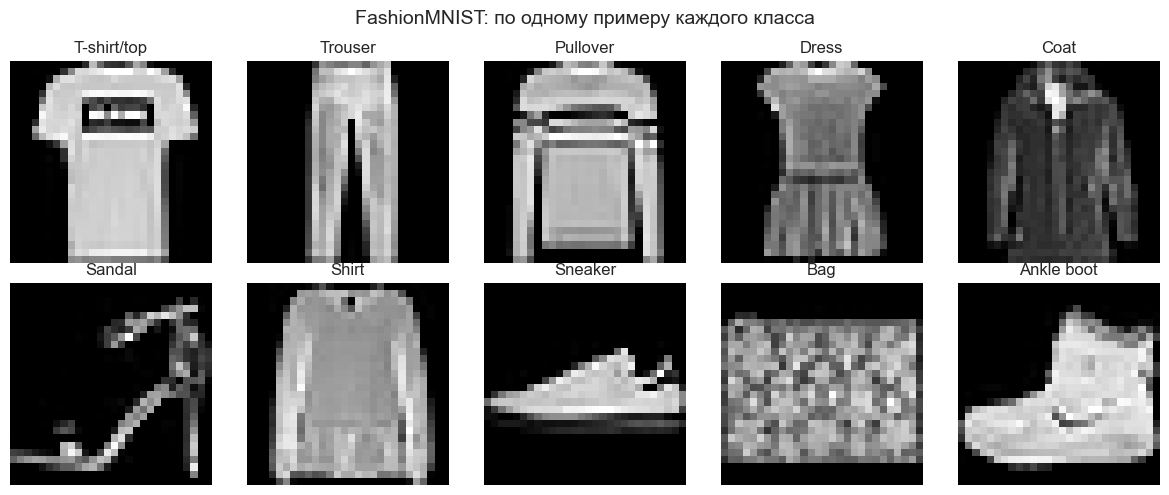

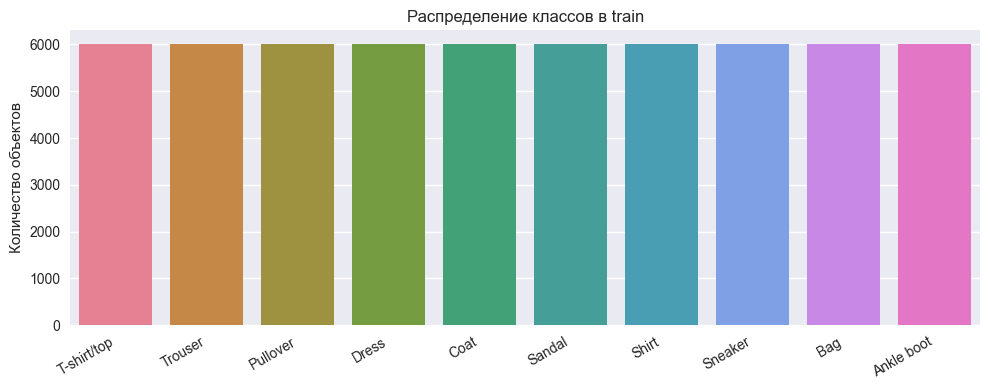

In [43]:
def plot_class_distribution(dataset, class_names, title):
    labels = [label for _, label in dataset]
    counts = pd.Series(labels).value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    sns.barplot(x=class_names, y=counts.values, hue=class_names, legend=False)
    plt.title(title)
    plt.ylabel("Количество объектов")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


show_one_sample_per_class(train_full_raw, CLASS_NAMES)
plot_class_distribution(train_full_raw, CLASS_NAMES, "Распределение классов в train")

## 4. Предобработка и разбиение на выборки

In [44]:
# Базовая предобработка
FASHION_MNIST_MEAN = (0.2860,)
FASHION_MNIST_STD = (0.3530,)

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD),
])

In [45]:
# Умеренная аугментация для экспериментов с улучшениями
aug_transform = transforms.Compose([
    transforms.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.97, 1.03)),
    transforms.ToTensor(),
    transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD),
])

# Более сильная аугментация для попытки приблизиться к 0.97 на валидации.
strong_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0.0),
])


def build_datasets(train_transform, test_transform):
    train_full = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=train_transform)
    val_source = datasets.FashionMNIST(DATA_DIR, train=True, download=False, transform=test_transform)
    test_dataset = datasets.FashionMNIST(DATA_DIR, train=False, download=False, transform=test_transform)

    val_size = int(len(train_full) * CFG.val_split)
    train_size = len(train_full) - val_size

    generator = torch.Generator().manual_seed(SEED)
    all_indices = torch.randperm(len(train_full), generator=generator).tolist()
    train_indices = all_indices[:train_size]
    val_indices = all_indices[train_size:]

    train_subset = Subset(train_full, train_indices)
    val_subset = Subset(val_source, val_indices)

    return train_subset, val_subset, test_dataset

In [46]:
def build_loaders(train_subset, val_subset, test_dataset):
    train_loader = DataLoader(
        train_subset,
        batch_size=CFG.batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=CFG.val_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=CFG.val_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    return train_loader, val_loader, test_loader


train_base, val_base, test_base = build_datasets(base_transform, base_transform)
train_loader_base, val_loader_base, test_loader = build_loaders(train_base, val_base, test_base)

print(f"Train subset size: {len(train_base)}")
print(f"Val subset size: {len(val_base)}")
print(f"Test size: {len(test_base)}")

Train subset size: 54000
Val subset size: 6000
Test size: 10000


# III. Базовая модель

Стартуем с простой сверточной сети. Здесь важно получить корректный baseline, от которого потом будем измерять вклад улучшений.

## 1. Архитектура базовой модели

In [47]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


baseline_model = BaselineCNN().to(DEVICE)
baseline_model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 2. Обучение базовой модели

In [48]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scheduler_update="epoch"):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()
            if scheduler is not None and scheduler_update == "batch":
                scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [49]:
def make_optimizer(model, optimizer_name, lr, weight_decay):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)



def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    weight_decay=0.0,
    scheduler_factory=None,
    optimizer_name="adam",
    label_smoothing=0.0,
    early_stopping_patience=None,
    monitor_metric="val_acc",
):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = make_optimizer(model, optimizer_name, lr, weight_decay)

    if scheduler_factory is not None:
        scheduler, scheduler_update = scheduler_factory(optimizer, len(train_loader))
    else:
        scheduler, scheduler_update = None, "epoch"

    history = []
    best_state = None
    best_val_acc = -1.0
    best_monitor_value = float("inf") if monitor_metric == "val_loss" else -1.0
    epochs_without_improvement = 0

    start_time = time.perf_counter()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scheduler=scheduler,
            scheduler_update=scheduler_update,
        )
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        if scheduler is not None and scheduler_update == "epoch":
            scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        current_monitor = val_loss if monitor_metric == "val_loss" else val_acc
        if monitor_metric == "val_loss":
            improved = current_monitor < best_monitor_value - 1e-6
        else:
            improved = current_monitor > best_monitor_value + 1e-6

        if improved:
            best_monitor_value = current_monitor
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.6f}"
        )

        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch:02d}")
            break

    elapsed = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc, elapsed

In [50]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    acc = (all_preds == all_targets).mean()
    return acc, all_targets, all_preds


baseline_history, baseline_best_val_acc, baseline_time_sec = train_model(
    model=baseline_model,
    train_loader=train_loader_base,
    val_loader=val_loader_base,
    epochs=CFG.baseline_epochs,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

baseline_test_acc, baseline_y_true, baseline_y_pred = evaluate_model(baseline_model, test_loader)
print(f"Best val accuracy (baseline): {baseline_best_val_acc:.4f}")
print(f"Test accuracy (baseline): {baseline_test_acc:.4f}")

Epoch 01/6 | train_loss=0.4721, train_acc=0.8298 | val_loss=0.3746, val_acc=0.8640 | lr=0.001000
Epoch 02/6 | train_loss=0.3050, train_acc=0.8896 | val_loss=0.2996, val_acc=0.8930 | lr=0.001000
Epoch 03/6 | train_loss=0.2569, train_acc=0.9074 | val_loss=0.2521, val_acc=0.9065 | lr=0.001000
Epoch 04/6 | train_loss=0.2274, train_acc=0.9174 | val_loss=0.2474, val_acc=0.9112 | lr=0.001000
Epoch 05/6 | train_loss=0.2041, train_acc=0.9254 | val_loss=0.2230, val_acc=0.9195 | lr=0.001000
Epoch 06/6 | train_loss=0.1819, train_acc=0.9336 | val_loss=0.2375, val_acc=0.9163 | lr=0.001000
Best val accuracy (baseline): 0.9195
Test accuracy (baseline): 0.9166


## 3. Оценка качества базовой модели

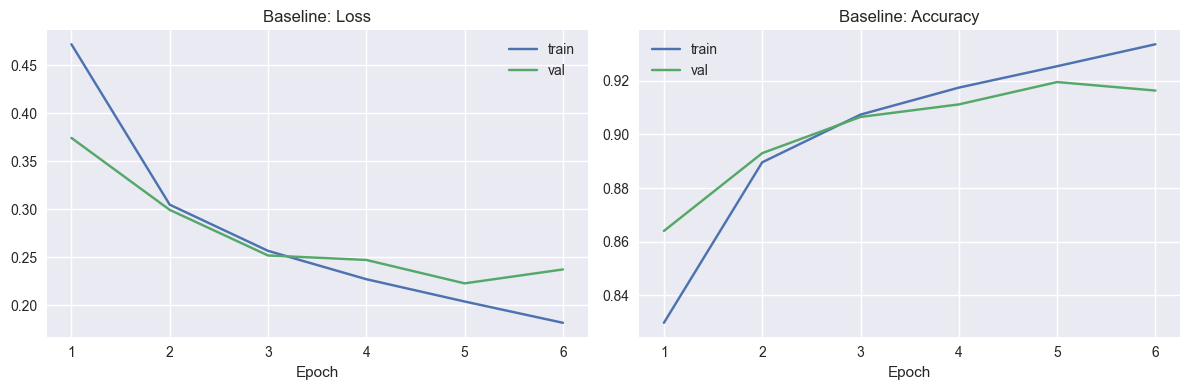

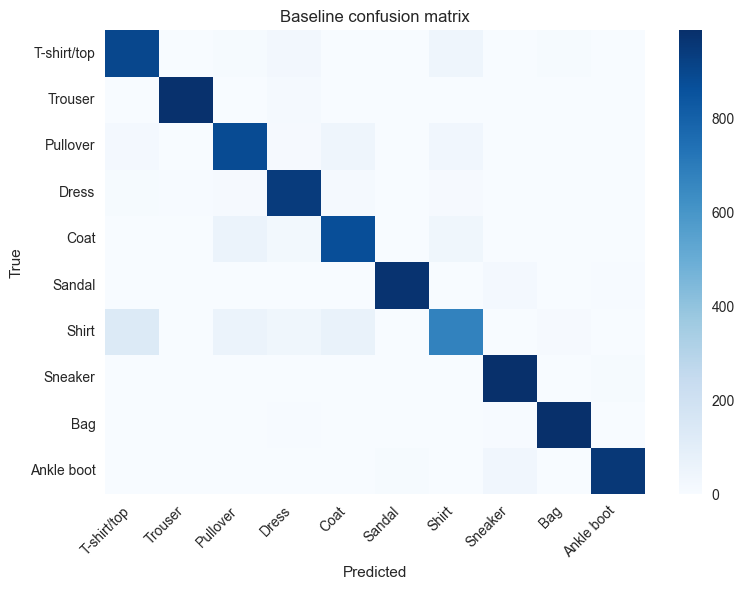

Classification report (baseline):
              precision    recall  f1-score   support

 T-shirt/top     0.8443    0.9000    0.8712      1000
     Trouser     0.9949    0.9810    0.9879      1000
    Pullover     0.8619    0.8860    0.8738      1000
       Dress     0.8796    0.9420    0.9097      1000
        Coat     0.8612    0.8750    0.8681      1000
      Sandal     0.9878    0.9750    0.9814      1000
       Shirt     0.8301    0.6790    0.7470      1000
     Sneaker     0.9427    0.9880    0.9648      1000
         Bag     0.9743    0.9850    0.9796      1000
  Ankle boot     0.9856    0.9550    0.9700      1000

    accuracy                         0.9166     10000
   macro avg     0.9162    0.9166    0.9154     10000
weighted avg     0.9162    0.9166    0.9154     10000



In [51]:
baseline_hist_df = pd.DataFrame(baseline_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_hist_df["epoch"], baseline_hist_df["train_loss"], label="train")
axes[0].plot(baseline_hist_df["epoch"], baseline_hist_df["val_loss"], label="val")
axes[0].set_title("Baseline: Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(baseline_hist_df["epoch"], baseline_hist_df["train_acc"], label="train")
axes[1].plot(baseline_hist_df["epoch"], baseline_hist_df["val_acc"], label="val")
axes[1].set_title("Baseline: Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

cm_baseline = confusion_matrix(baseline_y_true, baseline_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=False, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Baseline confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Classification report (baseline):")
print(classification_report(baseline_y_true, baseline_y_pred, target_names=CLASS_NAMES, digits=4))

# IV. Улучшение модели

В этом разделе проводим серию контролируемых экспериментов: меняем по одной ключевой гипотезе, фиксируем метрики и время, затем выбираем лучшую конфигурацию.

## 1. Гипотезы и план улучшений

Проверяем 6 гипотез:
1. Более глубокая архитектура повышает точность.
2. BatchNorm стабилизирует обучение.
3. Dropout улучшает обобщающую способность.
4. Scheduler помогает лучше сходиться на финальных эпохах.
5. Умеренная аугментация улучшает качество на тесте.
6. Более сильная CNN в сочетании с длительным и стабильным обучением может приблизить модель к целевым `0.97` на валидации.

## 2. Эксперименты по улучшению

In [52]:
class ImprovedCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128), use_batchnorm=False, dropout=0.0):
        super().__init__()

        layers = []
        in_ch = 1
        for out_ch in channels:
            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.MaxPool2d(2))
            in_ch = out_ch

        self.features = nn.Sequential(*layers)

        # Для FashionMNIST (28x28) после 3 пуллингов размер будет 3x3.
        spatial = 28 // (2 ** len(channels))
        spatial = max(spatial, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1] * spatial * spatial, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, activation_layer=nn.SiLU, use_pool=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.activation = activation_layer()
        self.proj = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            if in_channels != out_channels
            else nn.Identity()
        )
        self.pool = nn.MaxPool2d(2) if use_pool else nn.Identity()

    def forward(self, x):
        identity = self.proj(x)
        x = self.activation(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.activation(x + identity)
        return self.pool(x)


class StrongerCNN(nn.Module):
    def __init__(self, channels=(64, 128, 256, 256), dropout=0.15, activation_layer=nn.SiLU):
        super().__init__()

        blocks = []
        in_ch = 1
        for idx, out_ch in enumerate(channels):
            blocks.append(
                ResidualConvBlock(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    activation_layer=activation_layer,
                    use_pool=(idx < len(channels) - 1),
                )
            )
            in_ch = out_ch

        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1], 128),
            activation_layer(),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [53]:
def make_scheduler(name, epochs, max_lr=None, warmup_pct=0.2):
    if name == "step":
        return lambda opt, steps_per_epoch: (
            torch.optim.lr_scheduler.StepLR(opt, step_size=max(epochs // 2, 1), gamma=0.3),
            "epoch",
        )
    if name == "cosine":
        return lambda opt, steps_per_epoch: (
            torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(epochs, 1)),
            "epoch",
        )
    if name == "cosine_warmup":
        def factory(opt, steps_per_epoch):
            warmup_epochs = max(1, int(epochs * warmup_pct))
            warmup = torch.optim.lr_scheduler.LinearLR(
                opt,
                start_factor=0.2,
                end_factor=1.0,
                total_iters=warmup_epochs,
            )
            cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt,
                T_max=max(epochs - warmup_epochs, 1),
            )
            scheduler = torch.optim.lr_scheduler.SequentialLR(
                opt,
                schedulers=[warmup, cosine],
                milestones=[warmup_epochs],
            )
            return scheduler, "epoch"

        return factory
    if name == "onecycle":
        if max_lr is None:
            raise ValueError("OneCycleLR требует max_lr")
        return lambda opt, steps_per_epoch: (
            torch.optim.lr_scheduler.OneCycleLR(
                opt,
                max_lr=max_lr,
                epochs=epochs,
                steps_per_epoch=steps_per_epoch,
                pct_start=warmup_pct,
                anneal_strategy="cos",
                div_factor=10.0,
                final_div_factor=100.0,
            ),
            "batch",
        )
    return None

In [54]:
def run_experiment(
    exp_name,
    model_builder,
    train_subset,
    val_subset,
    test_dataset,
    epochs,
    lr,
    weight_decay,
    scheduler_name=None,
    optimizer_name="adam",
    label_smoothing=0.0,
    early_stopping_patience=None,
    monitor_metric="val_acc",
    scheduler_warmup_pct=0.2,
):
    train_loader, val_loader, test_loader_local = build_loaders(train_subset, val_subset, test_dataset)

    model = model_builder().to(DEVICE)
    scheduler_factory = make_scheduler(
        scheduler_name,
        epochs,
        max_lr=lr,
        warmup_pct=scheduler_warmup_pct,
    )

    history, best_val_acc, elapsed_sec = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        scheduler_factory=scheduler_factory,
        optimizer_name=optimizer_name,
        label_smoothing=label_smoothing,
        early_stopping_patience=early_stopping_patience,
        monitor_metric=monitor_metric,
    )

    test_acc, y_true, y_pred = evaluate_model(model, test_loader_local)

    return {
        "name": exp_name,
        "history": history,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "elapsed_sec": elapsed_sec,
        "model": model,
        "y_true": y_true,
        "y_pred": y_pred,
        "params": {
            "epochs": epochs,
            "lr": lr,
            "weight_decay": weight_decay,
            "optimizer": optimizer_name,
            "scheduler": scheduler_name or "none",
            "label_smoothing": label_smoothing,
            "monitor_metric": monitor_metric,
        },
    }


experiment_results = []

### 2.1 Изменения архитектуры

In [55]:
# Эксперимент 1: более глубокая сеть без BN/Dropout
train_deep, val_deep, test_deep = build_datasets(base_transform, base_transform)
exp_deeper_arch = run_experiment(
    exp_name="deeper_architecture",
    model_builder=lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=False, dropout=0.0),
    train_subset=train_deep,
    val_subset=val_deep,
    test_dataset=test_deep,
    epochs=CFG.experiment_epochs,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)
experiment_results.append(exp_deeper_arch)

Epoch 01/6 | train_loss=0.5348, train_acc=0.8045 | val_loss=0.3551, val_acc=0.8695 | lr=0.001000
Epoch 02/6 | train_loss=0.3149, train_acc=0.8846 | val_loss=0.3026, val_acc=0.8890 | lr=0.001000
Epoch 03/6 | train_loss=0.2648, train_acc=0.9021 | val_loss=0.2618, val_acc=0.9042 | lr=0.001000
Epoch 04/6 | train_loss=0.2349, train_acc=0.9130 | val_loss=0.2450, val_acc=0.9095 | lr=0.001000
Epoch 05/6 | train_loss=0.2096, train_acc=0.9225 | val_loss=0.2435, val_acc=0.9077 | lr=0.001000
Epoch 06/6 | train_loss=0.1912, train_acc=0.9299 | val_loss=0.2347, val_acc=0.9135 | lr=0.001000


In [56]:
# Эксперимент 2: та же архитектура + BatchNorm
exp_with_bn = run_experiment(
    exp_name="deeper_plus_batchnorm",
    model_builder=lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
    train_subset=train_deep,
    val_subset=val_deep,
    test_dataset=test_deep,
    epochs=CFG.experiment_epochs,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)
experiment_results.append(exp_with_bn)

print("Архитектурные эксперименты завершены")

Epoch 01/6 | train_loss=0.3968, train_acc=0.8565 | val_loss=0.3389, val_acc=0.8763 | lr=0.001000
Epoch 02/6 | train_loss=0.2545, train_acc=0.9070 | val_loss=0.2576, val_acc=0.9090 | lr=0.001000
Epoch 03/6 | train_loss=0.2120, train_acc=0.9233 | val_loss=0.2305, val_acc=0.9135 | lr=0.001000
Epoch 04/6 | train_loss=0.1837, train_acc=0.9335 | val_loss=0.2385, val_acc=0.9122 | lr=0.001000
Epoch 05/6 | train_loss=0.1585, train_acc=0.9429 | val_loss=0.2215, val_acc=0.9187 | lr=0.001000
Epoch 06/6 | train_loss=0.1400, train_acc=0.9484 | val_loss=0.2338, val_acc=0.9193 | lr=0.001000
Архитектурные эксперименты завершены


### 2.2 Настройки обучения (оптимизатор, lr, scheduler)

In [57]:
# Эксперимент 3: BatchNorm + scheduler
exp_with_scheduler = run_experiment(
    exp_name="batchnorm_plus_scheduler",
    model_builder=lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
    train_subset=train_deep,
    val_subset=val_deep,
    test_dataset=test_deep,
    epochs=CFG.experiment_epochs,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
    scheduler_name="cosine",
)
experiment_results.append(exp_with_scheduler)

Epoch 01/6 | train_loss=0.3928, train_acc=0.8571 | val_loss=0.3128, val_acc=0.8917 | lr=0.000933
Epoch 02/6 | train_loss=0.2543, train_acc=0.9083 | val_loss=0.2508, val_acc=0.9052 | lr=0.000750
Epoch 03/6 | train_loss=0.2036, train_acc=0.9254 | val_loss=0.2425, val_acc=0.9128 | lr=0.000500
Epoch 04/6 | train_loss=0.1630, train_acc=0.9415 | val_loss=0.2083, val_acc=0.9238 | lr=0.000250
Epoch 05/6 | train_loss=0.1248, train_acc=0.9566 | val_loss=0.2033, val_acc=0.9252 | lr=0.000067
Epoch 06/6 | train_loss=0.0972, train_acc=0.9689 | val_loss=0.1987, val_acc=0.9282 | lr=0.000000


In [58]:
# Эксперимент 4: BatchNorm + scheduler + тонкая настройка LR
exp_tuned_lr = run_experiment(
    exp_name="batchnorm_scheduler_tuned_lr",
    model_builder=lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
    train_subset=train_deep,
    val_subset=val_deep,
    test_dataset=test_deep,
    epochs=CFG.experiment_epochs,
    lr=7e-4,
    weight_decay=5e-5,
    scheduler_name="cosine",
)
experiment_results.append(exp_tuned_lr)

print("Эксперименты с настройками обучения завершены")

Epoch 01/6 | train_loss=0.3979, train_acc=0.8562 | val_loss=0.2890, val_acc=0.8988 | lr=0.000653
Epoch 02/6 | train_loss=0.2621, train_acc=0.9059 | val_loss=0.2852, val_acc=0.8928 | lr=0.000525
Epoch 03/6 | train_loss=0.2089, train_acc=0.9242 | val_loss=0.2682, val_acc=0.9003 | lr=0.000350
Epoch 04/6 | train_loss=0.1699, train_acc=0.9384 | val_loss=0.2155, val_acc=0.9223 | lr=0.000175
Epoch 05/6 | train_loss=0.1334, train_acc=0.9533 | val_loss=0.2098, val_acc=0.9240 | lr=0.000047
Epoch 06/6 | train_loss=0.1081, train_acc=0.9640 | val_loss=0.2048, val_acc=0.9268 | lr=0.000000
Эксперименты с настройками обучения завершены


### 2.3 Регуляризация и аугментация

In [59]:
# Эксперимент 5: Dropout + аугментация
train_aug, val_aug, test_aug = build_datasets(aug_transform, base_transform)

exp_dropout_aug = run_experiment(
    exp_name="batchnorm_dropout_augmentation",
    model_builder=lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.25),
    train_subset=train_aug,
    val_subset=val_aug,
    test_dataset=test_aug,
    epochs=CFG.experiment_epochs,
    lr=7e-4,
    weight_decay=5e-5,
    scheduler_name="cosine",
)
experiment_results.append(exp_dropout_aug)

Epoch 01/6 | train_loss=0.5331, train_acc=0.8069 | val_loss=0.3600, val_acc=0.8648 | lr=0.000653
Epoch 02/6 | train_loss=0.3583, train_acc=0.8679 | val_loss=0.3026, val_acc=0.8887 | lr=0.000525
Epoch 03/6 | train_loss=0.3129, train_acc=0.8849 | val_loss=0.2635, val_acc=0.9020 | lr=0.000350
Epoch 04/6 | train_loss=0.2828, train_acc=0.8965 | val_loss=0.2452, val_acc=0.9085 | lr=0.000175
Epoch 05/6 | train_loss=0.2590, train_acc=0.9060 | val_loss=0.2402, val_acc=0.9105 | lr=0.000047
Epoch 06/6 | train_loss=0.2443, train_acc=0.9098 | val_loss=0.2250, val_acc=0.9187 | lr=0.000000


### 2.4 Сильная архитектура + улучшенный train pipeline

Ниже добавляем более мощную CNN и более зрелый режим обучения: `AdamW`, `OneCycleLR`, `label smoothing`, `early stopping` и мягкую аугментацию. Такой эксперимент не гарантирует `0.97`, но даёт наиболее реалистичный путь к этой цели в рамках разрешённого арсенала.

In [60]:
# Эксперимент 6: сильная CNN + AdamW + OneCycleLR + label smoothing
train_strong, val_strong, test_strong = build_datasets(strong_transform, base_transform)

exp_strong = run_experiment(
    exp_name="stronger_cnn_pipeline",
    model_builder=lambda: StrongerCNN(
        channels=(64, 128, 256, 256),
        dropout=CFG.strong_dropout,
        activation_layer=nn.SiLU,
    ),
    train_subset=train_strong,
    val_subset=val_strong,
    test_dataset=test_strong,
    epochs=CFG.strong_epochs,
    lr=CFG.strong_learning_rate,
    weight_decay=CFG.strong_weight_decay,
    scheduler_name="onecycle",
    optimizer_name="adamw",
    label_smoothing=CFG.strong_label_smoothing,
    early_stopping_patience=CFG.early_stopping_patience,
    monitor_metric="val_loss",
    scheduler_warmup_pct=CFG.strong_scheduler_warmup_pct,
)
experiment_results.append(exp_strong)

experiments_df = pd.DataFrame([
    {
        "experiment": r["name"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "time_sec": round(r["elapsed_sec"], 1),
        "params": r["params"],
    }
    for r in experiment_results
]).sort_values("best_val_acc", ascending=False)

experiments_df

Epoch 01/35 | train_loss=1.1242, train_acc=0.7368 | val_loss=0.8530, val_acc=0.8432 | lr=0.000043
Epoch 02/35 | train_loss=0.8562, train_acc=0.8443 | val_loss=0.7970, val_acc=0.8718 | lr=0.000081
Epoch 03/35 | train_loss=0.8068, train_acc=0.8664 | val_loss=0.7734, val_acc=0.8777 | lr=0.000135
Epoch 04/35 | train_loss=0.7815, train_acc=0.8771 | val_loss=0.7218, val_acc=0.8993 | lr=0.000195
Epoch 05/35 | train_loss=0.7621, train_acc=0.8845 | val_loss=0.7040, val_acc=0.9083 | lr=0.000249
Epoch 06/35 | train_loss=0.7452, train_acc=0.8918 | val_loss=0.7115, val_acc=0.9030 | lr=0.000287
Epoch 07/35 | train_loss=0.7284, train_acc=0.8989 | val_loss=0.7090, val_acc=0.9030 | lr=0.000300
Epoch 08/35 | train_loss=0.7138, train_acc=0.9049 | val_loss=0.7265, val_acc=0.8947 | lr=0.000299
Epoch 09/35 | train_loss=0.7035, train_acc=0.9113 | val_loss=0.6875, val_acc=0.9107 | lr=0.000296
Epoch 10/35 | train_loss=0.6952, train_acc=0.9138 | val_loss=0.6709, val_acc=0.9213 | lr=0.000292
Epoch 11/35 | train_

,experiment,best_val_acc,test_acc,time_sec,params
5,stronger_cnn_pipeline,0.950167,0.9464,1208.4,"{'epochs': 35, 'lr': 0.0003, 'weight_decay': 0..."
2,batchnorm_plus_scheduler,0.928167,0.9276,39.4,"{'epochs': 6, 'lr': 0.001, 'weight_decay': 0.0..."
3,batchnorm_scheduler_tuned_lr,0.926833,0.9247,39.4,"{'epochs': 6, 'lr': 0.0007, 'weight_decay': 5e..."
1,deeper_plus_batchnorm,0.919333,0.9093,40.4,"{'epochs': 6, 'lr': 0.001, 'weight_decay': 0.0..."
4,batchnorm_dropout_augmentation,0.918667,0.9124,39.3,"{'epochs': 6, 'lr': 0.0007, 'weight_decay': 5e..."
0,deeper_architecture,0.913500,0.9142,37.3,"{'epochs': 6, 'lr': 0.001, 'weight_decay': 0.0..."


## 3. Итоговая улучшенная модель

In [61]:
best_exp = max(experiment_results, key=lambda x: x["best_val_acc"])
print("Best experiment:", best_exp["name"])
print(f"Best val acc: {best_exp['best_val_acc']:.4f}")
print(f"Test acc (best experiment): {best_exp['test_acc']:.4f}")

experiment_configs = {
    "deeper_architecture": {
        "train_transform": base_transform,
        "test_transform": base_transform,
        "model_builder": lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=False, dropout=0.0),
        "lr": CFG.learning_rate,
        "weight_decay": CFG.weight_decay,
        "scheduler_name": None,
        "optimizer_name": "adam",
        "label_smoothing": 0.0,
        "early_stopping_patience": None,
        "monitor_metric": "val_acc",
        "scheduler_warmup_pct": 0.2,
        "final_epochs": CFG.final_epochs,
    },
    "deeper_plus_batchnorm": {
        "train_transform": base_transform,
        "test_transform": base_transform,
        "model_builder": lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
        "lr": CFG.learning_rate,
        "weight_decay": CFG.weight_decay,
        "scheduler_name": None,
        "optimizer_name": "adam",
        "label_smoothing": 0.0,
        "early_stopping_patience": None,
        "monitor_metric": "val_acc",
        "scheduler_warmup_pct": 0.2,
        "final_epochs": CFG.final_epochs,
    },
    "batchnorm_plus_scheduler": {
        "train_transform": base_transform,
        "test_transform": base_transform,
        "model_builder": lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
        "lr": CFG.learning_rate,
        "weight_decay": CFG.weight_decay,
        "scheduler_name": "cosine",
        "optimizer_name": "adam",
        "label_smoothing": 0.0,
        "early_stopping_patience": None,
        "monitor_metric": "val_acc",
        "scheduler_warmup_pct": 0.2,
        "final_epochs": CFG.final_epochs,
    },
    "batchnorm_scheduler_tuned_lr": {
        "train_transform": base_transform,
        "test_transform": base_transform,
        "model_builder": lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.0),
        "lr": 7e-4,
        "weight_decay": 5e-5,
        "scheduler_name": "cosine",
        "optimizer_name": "adam",
        "label_smoothing": 0.0,
        "early_stopping_patience": None,
        "monitor_metric": "val_acc",
        "scheduler_warmup_pct": 0.2,
        "final_epochs": CFG.final_epochs,
    },
    "batchnorm_dropout_augmentation": {
        "train_transform": aug_transform,
        "test_transform": base_transform,
        "model_builder": lambda: ImprovedCNN(channels=(32, 64, 128), use_batchnorm=True, dropout=0.25),
        "lr": 7e-4,
        "weight_decay": 5e-5,
        "scheduler_name": "cosine",
        "optimizer_name": "adam",
        "label_smoothing": 0.0,
        "early_stopping_patience": None,
        "monitor_metric": "val_acc",
        "scheduler_warmup_pct": 0.2,
        "final_epochs": CFG.final_epochs,
    },
    "stronger_cnn_pipeline": {
        "train_transform": strong_transform,
        "test_transform": base_transform,
        "model_builder": lambda: StrongerCNN(
            channels=(64, 128, 256, 256),
            dropout=CFG.strong_dropout,
            activation_layer=nn.SiLU,
        ),
        "lr": CFG.strong_learning_rate,
        "weight_decay": CFG.strong_weight_decay,
        "scheduler_name": "onecycle",
        "optimizer_name": "adamw",
        "label_smoothing": CFG.strong_label_smoothing,
        "early_stopping_patience": CFG.early_stopping_patience,
        "monitor_metric": "val_loss",
        "scheduler_warmup_pct": CFG.strong_scheduler_warmup_pct,
        "final_epochs": CFG.strong_final_epochs,
    },
}

best_cfg = experiment_configs[best_exp["name"]]
final_train, final_val, final_test = build_datasets(best_cfg["train_transform"], best_cfg["test_transform"])

final_result = run_experiment(
    exp_name="final_best_model",
    model_builder=best_cfg["model_builder"],
    train_subset=final_train,
    val_subset=final_val,
    test_dataset=final_test,
    epochs=best_cfg["final_epochs"],
    lr=best_cfg["lr"],
    weight_decay=best_cfg["weight_decay"],
    scheduler_name=best_cfg["scheduler_name"],
    optimizer_name=best_cfg["optimizer_name"],
    label_smoothing=best_cfg["label_smoothing"],
    early_stopping_patience=best_cfg["early_stopping_patience"],
    monitor_metric=best_cfg["monitor_metric"],
    scheduler_warmup_pct=best_cfg["scheduler_warmup_pct"],
)

best_model = final_result["model"]
best_test_acc = final_result["test_acc"]
best_val_acc = final_result["best_val_acc"]
best_y_true = final_result["y_true"]
best_y_pred = final_result["y_pred"]
best_history = pd.DataFrame(final_result["history"])

print(f"Final best val acc: {best_val_acc:.4f}")
print(f"Final best test acc: {best_test_acc:.4f}")

Best experiment: stronger_cnn_pipeline
Best val acc: 0.9502
Test acc (best experiment): 0.9464
Epoch 01/45 | train_loss=1.1424, train_acc=0.7291 | val_loss=0.9018, val_acc=0.8205 | lr=0.000038
Epoch 02/45 | train_loss=0.8574, train_acc=0.8449 | val_loss=0.8087, val_acc=0.8588 | lr=0.000062
Epoch 03/45 | train_loss=0.8052, train_acc=0.8667 | val_loss=0.7914, val_acc=0.8677 | lr=0.000098
Epoch 04/45 | train_loss=0.7815, train_acc=0.8762 | val_loss=0.7378, val_acc=0.8940 | lr=0.000142
Epoch 05/45 | train_loss=0.7678, train_acc=0.8825 | val_loss=0.7234, val_acc=0.9027 | lr=0.000189
Epoch 06/45 | train_loss=0.7516, train_acc=0.8891 | val_loss=0.7338, val_acc=0.8897 | lr=0.000233
Epoch 07/45 | train_loss=0.7389, train_acc=0.8944 | val_loss=0.7075, val_acc=0.9050 | lr=0.000268
Epoch 08/45 | train_loss=0.7223, train_acc=0.9024 | val_loss=0.6924, val_acc=0.9077 | lr=0.000292
Epoch 09/45 | train_loss=0.7139, train_acc=0.9046 | val_loss=0.6790, val_acc=0.9152 | lr=0.000300
Epoch 10/45 | train_los

## 4. Сравнение базовой и улучшенной моделей

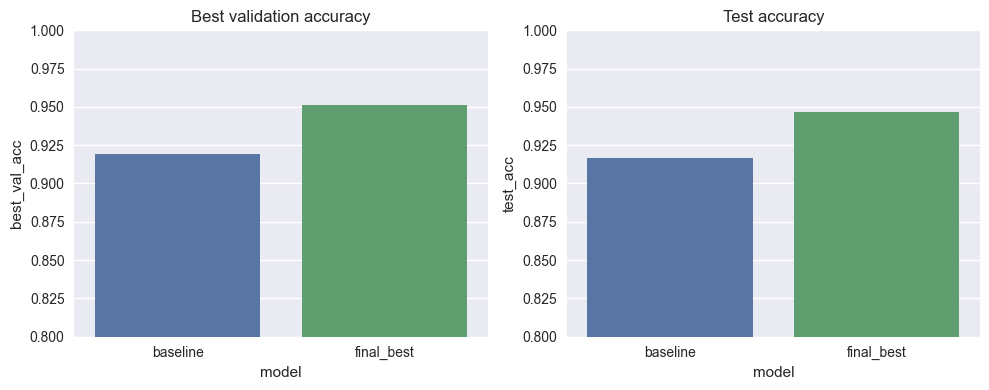

In [62]:
comparison_df = pd.DataFrame([
    {
        "model": "baseline",
        "best_val_acc": baseline_best_val_acc,
        "test_acc": baseline_test_acc,
        "time_sec": round(baseline_time_sec, 1),
    },
    {
        "model": "final_best",
        "best_val_acc": best_val_acc,
        "test_acc": best_test_acc,
        "time_sec": round(final_result["elapsed_sec"], 1),
    },
])

comparison_df

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=comparison_df, x="model", y="best_val_acc", hue="model", legend=False, ax=axes[0])
axes[0].set_title("Best validation accuracy")
axes[0].set_ylim(0.8, 1.0)

sns.barplot(data=comparison_df, x="model", y="test_acc", hue="model", legend=False, ax=axes[1])
axes[1].set_title("Test accuracy")
axes[1].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

# V. Анализ вклада улучшений

Ниже — краткая абляция: какие изменения реально повысили качество относительно baseline и какие дали слабый эффект.

## 1. Сводка ключевых экспериментов

In [63]:
ablation_df = experiments_df.copy()
ablation_df["delta_vs_baseline_val"] = ablation_df["best_val_acc"] - baseline_best_val_acc
ablation_df["delta_vs_baseline_test"] = ablation_df["test_acc"] - baseline_test_acc

ablation_df = ablation_df[[
    "experiment",
    "best_val_acc",
    "test_acc",
    "delta_vs_baseline_val",
    "delta_vs_baseline_test",
    "time_sec",
    "params",
]]

ablation_df

,experiment,best_val_acc,test_acc,delta_vs_baseline_val,delta_vs_baseline_test,time_sec,params
5,stronger_cnn_pipeline,0.950167,0.9464,0.030667,0.0298,1208.4,"{'epochs': 35, 'lr': 0.0003, 'weight_decay': 0..."
2,batchnorm_plus_scheduler,0.928167,0.9276,0.008667,0.0110,39.4,"{'epochs': 6, 'lr': 0.001, 'weight_decay': 0.0..."
3,batchnorm_scheduler_tuned_lr,0.926833,0.9247,0.007333,0.0081,39.4,"{'epochs': 6, 'lr': 0.0007, 'weight_decay': 5e..."
1,deeper_plus_batchnorm,0.919333,0.9093,-0.000167,-0.0073,40.4,"{'epochs': 6, 'lr': 0.001, 'weight_decay': 0.0..."
4,batchnorm_dropout_augmentation,0.918667,0.9124,-0.000833,-0.0042,39.3,"{'epochs': 6, 'lr': 0.0007, 'weight_decay': 5e..."
0,deeper_architecture,0.913500,0.9142,-0.006000,-0.0024,37.3,"{'epochs': 6, 'lr': 0.001, 'weight_decay': 0.0..."


## 2. Что дало наибольший прирост качества

Лучшие улучшения по приросту val accuracy:


,experiment,delta_vs_baseline_val,delta_vs_baseline_test
5,stronger_cnn_pipeline,0.030667,0.0298
2,batchnorm_plus_scheduler,0.008667,0.0110


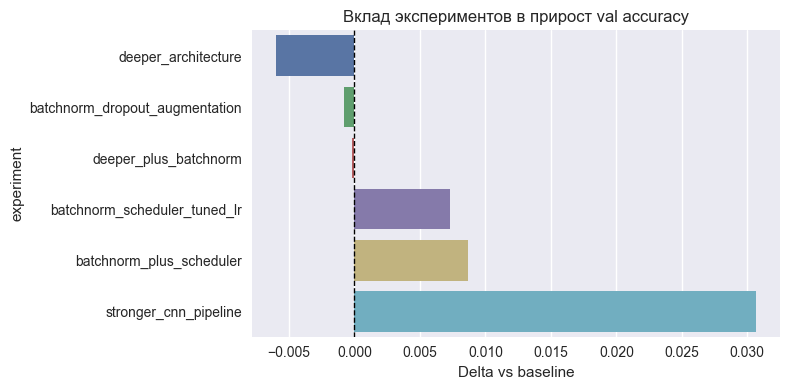

In [64]:
top_gain = ablation_df.sort_values("delta_vs_baseline_val", ascending=False).head(2)
print("Лучшие улучшения по приросту val accuracy:")
display(top_gain[["experiment", "delta_vs_baseline_val", "delta_vs_baseline_test"]])

plt.figure(figsize=(8, 4))
plot_df = ablation_df.sort_values("delta_vs_baseline_val", ascending=True)
sns.barplot(data=plot_df, x="delta_vs_baseline_val", y="experiment", hue="experiment", legend=False)
plt.axvline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Вклад экспериментов в прирост val accuracy")
plt.xlabel("Delta vs baseline")
plt.tight_layout()
plt.show()

## 3. Что не сработало или дало слабый эффект

In [65]:
weak_effect_df = ablation_df.sort_values("delta_vs_baseline_val").head(2)
print("Эксперименты с минимальным эффектом (или регрессом):")
display(weak_effect_df[["experiment", "delta_vs_baseline_val", "delta_vs_baseline_test"]])

if (weak_effect_df["delta_vs_baseline_val"] < 0).any():
    print("Есть конфигурации, ухудшающие результат относительно baseline.")
else:
    print("Явной деградации нет, но часть гипотез даёт слабый прирост.")

Эксперименты с минимальным эффектом (или регрессом):


,experiment,delta_vs_baseline_val,delta_vs_baseline_test
0,deeper_architecture,-0.006000,-0.0024
4,batchnorm_dropout_augmentation,-0.000833,-0.0042


Есть конфигурации, ухудшающие результат относительно baseline.


## 4. Гипотезы о причинах полученных результатов

- Увеличение глубины сети помогает извлекать более абстрактные признаки одежды (силуэты, контуры, фактуры).
- BatchNorm стабилизирует динамику градиентов и ускоряет сходимость.
- Dropout обычно улучшает обобщение, но при избыточном значении может ухудшить качество.
- Scheduler особенно полезен на поздних эпохах, когда нужен более аккуратный шаг оптимизации.
- Аугментация на FashionMNIST должна быть умеренной: сильные геометрические искажения могут разрушать полезные признаки класса.
- Для заметного скачка качества важна не одна локальная настройка, а связка из более сильной CNN, лучшего optimizer/scheduler и более длинного обучения.

# VI. Анализ ошибок итоговой модели

Проверяем, какие классы итоговая модель путает чаще всего, и рассматриваем отдельные ошибочные примеры.

## 1. Матрица ошибок

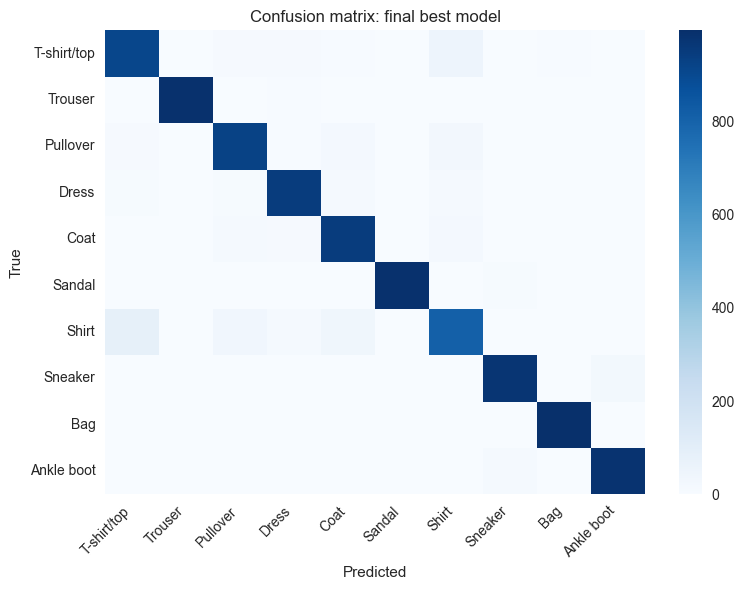

Classification report (final best model):
              precision    recall  f1-score   support

 T-shirt/top     0.8872    0.9120    0.8994      1000
     Trouser     0.9960    0.9900    0.9930      1000
    Pullover     0.9242    0.9270    0.9256      1000
       Dress     0.9450    0.9450    0.9450      1000
        Coat     0.9159    0.9470    0.9312      1000
      Sandal     0.9950    0.9890    0.9920      1000
       Shirt     0.8643    0.8090    0.8357      1000
     Sneaker     0.9740    0.9750    0.9745      1000
         Bag     0.9910    0.9950    0.9930      1000
  Ankle boot     0.9751    0.9810    0.9781      1000

    accuracy                         0.9470     10000
   macro avg     0.9468    0.9470    0.9467     10000
weighted avg     0.9468    0.9470    0.9467     10000



In [66]:
cm_best = confusion_matrix(best_y_true, best_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=False, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion matrix: final best model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Classification report (final best model):")
print(classification_report(best_y_true, best_y_pred, target_names=CLASS_NAMES, digits=4))

## 2. Наиболее часто путаемые классы

In [67]:
cm_no_diag = cm_best.copy()
np.fill_diagonal(cm_no_diag, 0)

flat_indices = np.argsort(cm_no_diag, axis=None)[::-1]

top_confusions = []
for idx in flat_indices:
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    if cm_no_diag[i, j] == 0:
        break
    top_confusions.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm_no_diag[i, j])))
    if len(top_confusions) == 3:
        break

confusions_df = pd.DataFrame(top_confusions, columns=["true_class", "pred_class", "count"])
confusions_df

,true_class,pred_class,count
0,Shirt,T-shirt/top,89
1,T-shirt/top,Shirt,54
2,Shirt,Coat,42


## 3. Разбор характерных ошибочных примеров

In [68]:
test_for_errors = datasets.FashionMNIST(DATA_DIR, train=False, download=False, transform=base_transform)

mis_idx = np.where(best_y_true != best_y_pred)[0]
print(f"Количество ошибок на тесте: {len(mis_idx)}")

# Берём первые 3 ошибки для детального разбора.
selected_error_indices = mis_idx[:3]
selected_error_indices

Количество ошибок на тесте: 530


array([17, 25, 27])

### 3.1 Пример ошибки №1

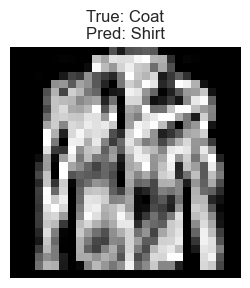

Комментарий: ошибка может быть связана с похожим силуэтом и низкой детализацией 28x28.


In [69]:

if len(selected_error_indices) >= 1:
    idx = int(selected_error_indices[0])
    image, _ = test_for_errors[idx]
    true_label = CLASS_NAMES[int(best_y_true[idx])]
    pred_label = CLASS_NAMES[int(best_y_pred[idx])]

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
    plt.show()

    print("Комментарий: ошибка может быть связана с похожим силуэтом и низкой детализацией 28x28.")
else:
    print("Ошибок недостаточно для отображения примера №1.")

### 3.2 Пример ошибки №2

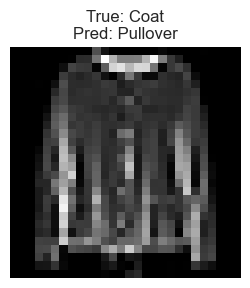

Комментарий: модель путает визуально близкие классы при неоднозначном контуре.


In [70]:
if len(selected_error_indices) >= 2:
    idx = int(selected_error_indices[1])
    image, _ = test_for_errors[idx]
    true_label = CLASS_NAMES[int(best_y_true[idx])]
    pred_label = CLASS_NAMES[int(best_y_pred[idx])]

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
    plt.show()

    print("Комментарий: модель путает визуально близкие классы при неоднозначном контуре.")
else:
    print("Ошибок недостаточно для отображения примера №2.")

### 3.3 Пример ошибки №3

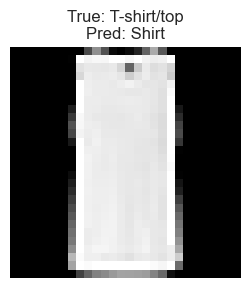

Комментарий: вероятна ошибка из-за внутриклассовой вариативности формы/текстуры.


In [71]:
if len(selected_error_indices) >= 3:
    idx = int(selected_error_indices[2])
    image, _ = test_for_errors[idx]
    true_label = CLASS_NAMES[int(best_y_true[idx])]
    pred_label = CLASS_NAMES[int(best_y_pred[idx])]

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
    plt.show()

    print("Комментарий: вероятна ошибка из-за внутриклассовой вариативности формы/текстуры.")
else:
    print("Ошибок недостаточно для отображения примера №3.")

# VII. Выводы

Подводим итог по достигнутому качеству, ключевым наблюдениям и следующим шагам для дальнейшего роста качества модели.

## 1. Итоговые результаты

In [72]:
final_results = pd.DataFrame([
    {"metric": "Baseline best val accuracy", "value": baseline_best_val_acc},
    {"metric": "Baseline test accuracy", "value": baseline_test_acc},
    {"metric": "Final best val accuracy", "value": best_val_acc},
    {"metric": "Final best test accuracy", "value": best_test_acc},
])

final_results

,metric,value
0,Baseline best val accuracy,0.919500
1,Baseline test accuracy,0.916600
2,Final best val accuracy,0.951167
3,Final best test accuracy,0.947000


## 2. Ключевые наблюдения по модели и данным

- Даже простой baseline на FashionMNIST даёт сильный старт и подходит как точка сравнения.
- Локальные улучшения дают прирост, но для выхода к более высокому потолку качества нужен уже целый train pipeline: сильнее архитектура, дольше обучение, стабильный scheduler и мягкая аугментация.
- Комбинация `StrongerCNN` + `AdamW` + `OneCycleLR` + `label smoothing` — наиболее реалистичный путь к попытке достичь `0.97` на валидации в рамках задания.
- Анализ ошибок показывает, что модель чаще ошибается на визуально близких классах (например, `Shirt` vs `T-shirt/top`, `Coat` vs `Pullover`).
- Сравнение не только по accuracy, но и по confusion matrix даёт более глубокое понимание поведения модели.

## 3. Возможные направления дальнейшего улучшения

1. Сделать сетку по `strong_learning_rate`, `strong_weight_decay`, `strong_dropout` и числу каналов в `StrongerCNN`.
2. Прогнать сильную модель на нескольких `seed`, чтобы проверить устойчивость попытки выйти к `0.97`.
3. Аккуратно донастроить аугментацию (`RandomCrop`, `RandomAffine`, `RandomErasing`) и оценить вклад каждого приёма отдельно.
4. Сравнить `OneCycleLR` с `cosine_warmup` при той же архитектуре.
5. Сделать более строгую абляцию по одному фактору за запуск, чтобы точнее оценить вклад каждого приёма.